In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180,
                     'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)
BILLION = 1e9
ALPHA = 0.05
YEARS = [1400, 1401, 1402, 1403]
COLUMNS = ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
           'created_at_month', 'price_mode', 'price_value', 'land_size',
           'building_size', 'regular_person_capacity', 'rooms_count',
           'location_latitude', 'location_longitude', 'has_business_deed',
           'deed_type', 'construction_year']
candidates = [Path('data/Divar_selected.csv.gz'), Path('Divar.csv'), Path('data/Divar.csv')]
DATA = next((p for p in candidates if p.exists()), None)
if DATA is None:
    raise FileNotFoundError('Extract the ZIP package first, or place Divar.csv beside the notebook.')
raw = pd.read_csv(DATA, usecols=COLUMNS, dtype=str)
print(f'Rows: {len(raw):,}; selected columns: {len(raw.columns)}')
print({'pandas': pd.__version__, 'numpy': np.__version__,
       'scipy': scipy.__version__, 'matplotlib': matplotlib.__version__})
display(raw.groupby('cat2_slug', dropna=False).size().rename('rows').to_frame())


Rows: 1,000,000; selected columns: 16
{'pandas': '2.2.3', 'numpy': '2.3.5', 'scipy': '1.17.0', 'matplotlib': '3.10.8'}


,rows
cat2_slug,
commercial-rent,76567
commercial-sell,38861
real-estate-services,19403
residential-rent,276558
residential-sell,558708
temporary-rent,29903


## آماده‌سازی مشترک و تعریف جامعه تحلیل

- قیمت فروش فقط در دو دسته `residential-sell` و `commercial-sell` استفاده می‌شود؛ اجاره، اجاره موقت و خدمات/پیش‌فروش با آن مخلوط نمی‌شوند.
- قیمت ناموجود، غیرعددی، نامتناهی و صفر از تحلیل قیمت فروش کنار گذاشته می‌شود. قیمت بزرگ صرفاً به دلیل بزرگی از پاسخ اصلی حذف نمی‌شود.
- مقادیر ناموجود با صفر یا میانگین جایگزین نمی‌شوند. به‌ویژه سند نامشخص به معنای «بدون سند» نیست.
- تعداد اتاق‌ها به ۰ تا ۵ تبدیل می‌شود. «پنج یا بیشتر» در داده یک دسته سقف‌گذاری‌شده است؛ عدد ۵ تعداد دقیق اتاق‌های همه این موارد نیست.
- هر ردیف یک آگهی است. تطابق چند ستون بین دو آگهی، اثبات تکراری بودن آن‌ها نیست؛ بدون شناسه واقعی ملک، حذف تکراری بر اساس این زیرمجموعه انجام نمی‌شود.
- `created_at_month` فقط ماه میلادی را نگه می‌دارد و همه روزها ۱ هستند. برای سؤال ۷، سال شمسیِ تاریخ ثبت‌شده مبناست.
  بنابراین آگهی‌های ماه مارس در سالِ روز اول مارس قرار می‌گیرند؛ تاریخ دقیق انتشار برای تفکیک قبل/بعد نوروز موجود نیست.
  اثر کنار گذاشتن ماه مارس جداگانه بررسی می‌شود.


In [2]:
df = raw.copy()
NUMERIC = ['price_value', 'land_size', 'building_size', 'regular_person_capacity',
           'location_longitude', 'location_latitude']
for col in NUMERIC:
    df[col] = pd.to_numeric(df[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
room_map = {'بدون اتاق': 0, 'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'پنج یا بیشتر': 5}
unmapped_rooms = sorted(set(raw['rooms_count'].dropna()) - set(room_map))
if unmapped_rooms:
    raise ValueError(f'Unmapped room categories: {unmapped_rooms}')
df['rooms_count'] = raw['rooms_count'].map(room_map)
df['business_deed'] = raw['has_business_deed'].map({'True': True, 'False': False})
for col in ['land_size', 'building_size', 'regular_person_capacity']:
    df.loc[df[col] <= 0, col] = np.nan
df.loc[~df['location_latitude'].between(-90, 90), 'location_latitude'] = np.nan
df.loc[~df['location_longitude'].between(-180, 180), 'location_longitude'] = np.nan

df['date'] = pd.to_datetime(raw['created_at_month'], errors='coerce')
boundaries = pd.to_datetime(['2021-03-21', '2022-03-21', '2023-03-21',
                             '2024-03-20', '2025-03-21'])
df['jalali_year'] = pd.cut(df['date'], bins=boundaries, labels=YEARS,
                           right=False).astype('Int64')
sale_mask = df['cat2_slug'].isin(['residential-sell', 'commercial-sell'])
price_ok = df['price_value'].notna() & (df['price_value'] > 0)
valid_sale = sale_mask & price_ok
audit = pd.DataFrame({'metric': [
    'All source rows', 'Sale-category rows', 'Positive sale prices',
    'Zero sale prices excluded', 'Missing sale prices excluded',
    'Positive prices outside sale categories excluded', 'Top-coded rooms (5+)'],
    'count': [len(df), int(sale_mask.sum()), int(valid_sale.sum()),
              int((sale_mask & df.price_value.eq(0)).sum()),
              int((sale_mask & df.price_value.isna()).sum()),
              int((~sale_mask & price_ok).sum()), int(raw.rooms_count.eq('پنج یا بیشتر').sum())]})
audit.to_csv(OUT / 'data_audit.csv', index=False)
display(audit)
print('All recorded dates have day=1:', bool(df['date'].dropna().dt.day.eq(1).all()))


All recorded dates have day=1: True


,metric,count
0,All source rows,1000000
1,Sale-category rows,597569
2,Positive sale prices,565190
3,Zero sale prices excluded,1901
4,Missing sale prices excluded,30478
5,Positive prices outside sale categories excluded,1254
6,Top-coded rooms (5+),13864


## آزمون فرض ۳: سند تجاری و میانگین قیمت فروش ملک تجاری

جامعه: فقط `cat2_slug == 'commercial-sell'`، با `price_value > 0` و وضعیت سند مشخص.
مقدار `False` یعنی «نداشتن سند تجاری در فیلد آگهی»، نه لزوماً نداشتن هر نوع سند مالکیت.

فرض صفر: $H_0:\mu_{True}=\mu_{False}$

فرض مقابل دوطرفه: $H_1:\mu_{True}\ne\mu_{False}$

سطح معناداری ۵٪ است. از **آزمون t مستقل ولچ (Welch)** استفاده می‌کنیم چون برابری واریانس دو گروه فرض نشده است.
آزمون اصلی روی قیمت اسمی و میانگین حسابی اصلی است؛ لگاریتم قیمت، میانه یا رتبه‌ها جای آن را نمی‌گیرند.
تعداد مشاهدات بزرگ است، ولی قیمت‌های پرت می‌توانند واریانس و نتیجه را شدیداً تغییر دهند؛ این محدودیت با تحلیل حساسیت بررسی می‌شود.
استقلال آگهی‌ها برای استنباط فرض شده است؛ شناسه ملک برای ارزیابی آگهی‌های تکراری در دست نیست.


Commercial-sale rows: 38861
Positive-price commercial-sale rows: 31929
Positive-price rows with unknown deed excluded: 3540


,count,mean,median,std,min,max
business_deed,,,,,,
No commercial deed (False),14262,2.62638e+10,2.9e+09,9.37952e+11,1,1e+14
Commercial deed (True),14127,2.76374e+10,3.85e+09,5.37817e+11,1,4e+13


,value
analysis,Primary: original positive sale prices
n_true,14127
n_false,14262
mean_true,2.76374e+10
mean_false,2.62638e+10
difference_true_minus_false,1.37362e+09
difference_pct_of_false,5.23007
t_statistic,0.151543
degrees_of_freedom,"22,767"
p_value,0.879549


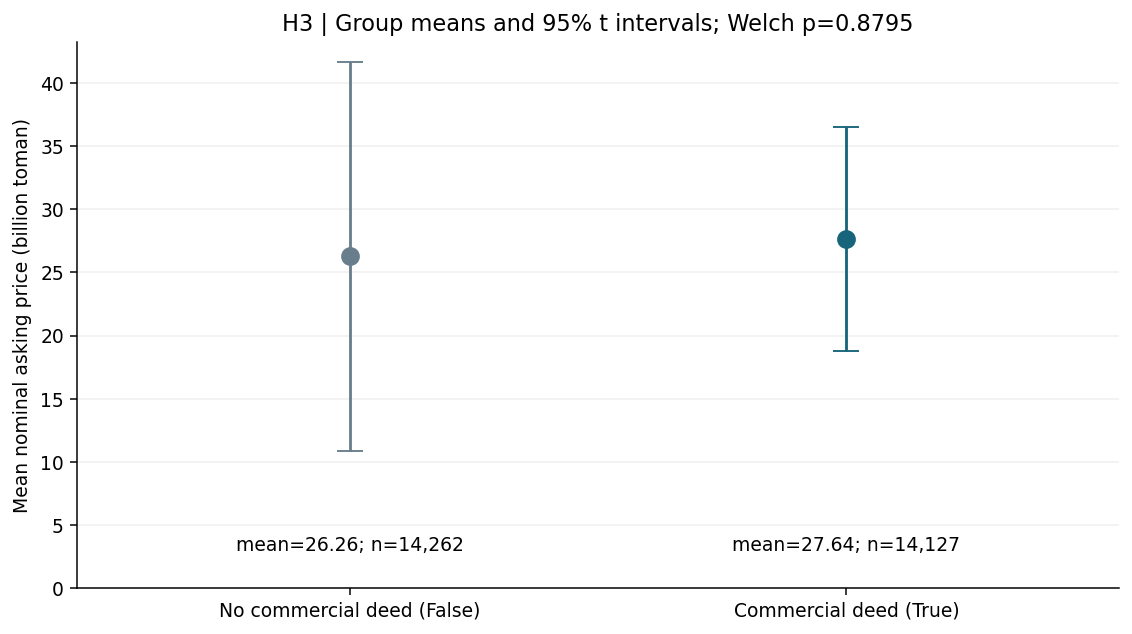

In [6]:
commercial = df.loc[df.cat2_slug.eq('commercial-sell')].copy()
study = commercial.loc[(commercial.price_value > 0) & commercial.business_deed.notna()].copy()
with_deed = study.loc[study.business_deed.eq(True), 'price_value'].to_numpy()
without_deed = study.loc[study.business_deed.eq(False), 'price_value'].to_numpy()
groups = study.groupby('business_deed').price_value.agg(['count', 'mean', 'median', 'std', 'min', 'max'])
groups.index = groups.index.map({False: 'No commercial deed (False)', True: 'Commercial deed (True)'})
groups.to_csv(OUT / 'h3_group_statistics.csv')
print('Commercial-sale rows:', len(commercial))
print('Positive-price commercial-sale rows:', int((commercial.price_value > 0).sum()))
print('Positive-price rows with unknown deed excluded:',
      int(((commercial.price_value > 0) & commercial.business_deed.isna()).sum()))
display(groups)

def welch_result(a, b, name):
    result = stats.ttest_ind(a, b, equal_var=False, alternative='two-sided')
    ci = result.confidence_interval(confidence_level=.95)
    return {'analysis': name, 'n_true': len(a), 'n_false': len(b),
            'mean_true': float(a.mean()), 'mean_false': float(b.mean()),
            'difference_true_minus_false': float(a.mean() - b.mean()),
            'difference_pct_of_false': float((a.mean() / b.mean() - 1) * 100),
            't_statistic': float(result.statistic), 'degrees_of_freedom': float(result.df),
            'p_value': float(result.pvalue), 'ci95_low': float(ci.low), 'ci95_high': float(ci.high),
            'reject_H0_at_0_05': bool(result.pvalue < ALPHA)}
primary_test = welch_result(with_deed, without_deed, 'Primary: original positive sale prices')
display(pd.DataFrame([primary_test]).T.rename(columns={0: 'value'}))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for pos, values, color in [(0, without_deed, '#687e8c'), (1, with_deed, '#17647b')]:
    half_width = stats.t.ppf(.975, len(values) - 1) * stats.sem(values)
    ax.errorbar(pos, values.mean() / BILLION, yerr=half_width / BILLION,
                fmt='o', markersize=9, capsize=7, color=color)
    ax.text(pos, 3, f'mean={values.mean()/BILLION:.2f}; n={len(values):,}', ha='center')
ax.set_xticks([0, 1], ['No commercial deed (False)', 'Commercial deed (True)'])
ax.set_xlim(-.55, 1.55)
ax.set_ylim(bottom=0)
ax.set(ylabel='Mean nominal asking price (billion toman)',
       title=f'H3 | Group means and 95% t intervals; Welch p={primary_test["p_value"]:.4f}')
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
fig.savefig(FIG / 'h3_group_means.png')
plt.show()
plt.close(fig)


### حساسیت آزمون به قیمت‌های افراطی

برای تشخیص میزان حساسیت، صدک‌های ۱ و ۹۹ را روی مجموعه هر دو گروه با هم محاسبه می‌کنیم و
**آستانه‌های یکسان** را بر دو گروه اعمال می‌کنیم. این آزمون دوم میانگین وینزورشده را بررسی می‌کند، نه همان میانگین حسابی خام.
انتخاب آستانه بر اساس رسیدن به p مطلوب انجام نشده است. پاسخ اصلی و این پاسخ مکمل جداگانه گزارش می‌شوند.


In [7]:
h3_low, h3_high = study.price_value.quantile([.01, .99])
clipped_true = np.clip(with_deed, h3_low, h3_high)
clipped_false = np.clip(without_deed, h3_low, h3_high)
sensitivity_test = welch_result(clipped_true, clipped_false, 'Sensitivity: pooled 1%-99% winsorization')
tests = pd.DataFrame([primary_test, sensitivity_test])
tests.to_csv(OUT / 'h3_welch_results.csv', index=False)
display(tests)
print('Shared winsorization bounds:', h3_low, h3_high)
print('Rows changed by winsorization:', int(((study.price_value < h3_low) | (study.price_value > h3_high)).sum()))
print('Positive prices below one million:', int((study.price_value < 1e6).sum()))
print('Largest listed prices:', study.price_value.nlargest(8).tolist())
subtype_table = study.groupby(['cat3_slug', 'business_deed']).price_value.agg(['count', 'mean', 'median'])
subtype_table.to_csv(OUT / 'h3_property_subtypes.csv')
display(subtype_table)


Shared winsorization bounds: 398.31999999999994 160000000000.0
Rows changed by winsorization: 565
Positive prices below one million: 1131
Largest listed prices: [99999999999999.0, 40000000000000.0, 38000000000000.0, 35000000000000.0, 17500000000000.0, 15000000000000.0, 13000000000000.0, 11111111111111.0]


,analysis,n_true,n_false,mean_true,mean_false,difference_true_minus_false,difference_pct_of_false,t_statistic,degrees_of_freedom,p_value,ci95_low,ci95_high,reject_H0_at_0_05
0,Primary: original positive sale prices,14127,14262,2.76374e+10,2.62638e+10,1.37362e+09,5.23007,0.151543,"22,767",0.879549,-1.63929e+10,1.91401e+10,False
1,Sensitivity: pooled 1%-99% winsorization,14127,14262,1.13576e+10,8.73414e+09,2.62342e+09,30.0364,9.87856,"27,481",5.6323e-23,2.1029e+09,3.14395e+09,True


count        mean   median
cat3_slug                          business_deed                            
industry-agriculture-business-sell False           4026 1.43609e+10  1.8e+09
                                   True            4361 2.30003e+10  3.5e+09
office-sell                        False           1506 2.01842e+10 5.85e+09
                                   True            2089 2.93065e+10  6.5e+09
shop-sell                          False           8730 3.28019e+10 2.98e+09
                                   True            7677 2.98174e+10  3.4e+09

**پاسخ آزمون فرض:** در تحلیل اصلی، مقدار p حدود **۰٫۸۷۹۵** است؛ در سطح ۵٪ فرض صفر رد نمی‌شود.
میانگین گروه دارای سند تجاری حدود **۲۷٫۶۴** و گروه فاقد سند تجاری حدود **۲۶٫۲۶ میلیارد تومان** است.
فاصله اطمینان ۹۵٪ اختلاف میانگین‌ها حدود **۱۶٫۳۹− تا ۱۹٫۱۴ میلیارد تومان** است و صفر را در بر می‌گیرد.
بنابراین با این داده‌ها و این آزمون، شواهد کافی برای تفاوت معنادار میانگین حسابی اصلی نداریم؛ این به معنای اثبات برابری یا بی‌اثر بودن سند نیست.

در بررسی حساسیت با وینزور ۱٪، میانگین‌ها به حدود **۱۱٫۳۶** و **۸٫۷۳ میلیارد تومان** می‌رسند و مقدار p حدود **۵٫۶۳×۱۰⁻²³** است.
اختلاف میانگین وینزورشده حدود **۲٫۶۲ میلیارد تومان** و فاصله اطمینان آن **۲٫۱۰ تا ۳٫۱۴ میلیارد تومان** است.
تغییر نتیجه نشان می‌دهد استنباط درباره میانگین به قیمت‌های افراطی حساس است؛ نتیجه مثبت تحلیل مکمل نباید جای پاسخ آزمون اصلی معرفی شود.

این بررسی مشاهده‌ای، **ارتباط یا تفاوت میانگین ثبت‌شده** را می‌سنجد و اثر علّی سند را ثابت نمی‌کند.
اندازه ملک، شهر، نوع ملک تجاری و زمان آگهی در این آزمون دوگروهی کنترل نشده‌اند.


## کنترل محاسبات و منابع

در سلول آخر، فرمول مستقیم t ولچ و فاصله اطمینان با خروجی SciPy تطبیق داده می‌شود؛ تقارن ماتریس‌ها و
تعداد مشاهدات نیز بررسی می‌شوند. فایل‌های CSV در `outputs` و تصاویر در `outputs/figures` ذخیره می‌شوند.

- [فایل اصلی داده معرفی‌شده در PDF](https://drive.google.com/file/d/1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ/view?usp=drivesdk)
- SHA-256 فایل اصلی: `a5b1213a5026e162696e7e9c40cca0ffd845d4bc0755d2dbc82e3a2ab245af18`
- منابع CPI در بخش سؤال ۷ آمده‌اند؛ تاریخ دسترسی: ۲۲ سپتامبر ۲۰۲۶.
- [مستندات رسمی Pearson/Spearman و حذف جفتی در pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
- [مستندات رسمی آزمون ولچ و فاصله اطمینان در SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
